In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
import pandas as pd

def get_third_wednesday(year: int, month: int) -> pd.Timestamp:
    first_day = pd.Timestamp(year=year, month=month, day=1)
    offset = (2 - first_day.weekday()) % 7
    first_wed = first_day + pd.Timedelta(days=offset)
    return first_wed + pd.Timedelta(weeks=2)

def get_settlement_dates(start_date, end_date, trading_days):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    trading_days = pd.to_datetime(trading_days)
    trading_days = pd.DatetimeIndex(sorted(pd.Series(trading_days).dropna().unique()))

    months = pd.date_range(
        start=start_date.replace(day=1),
        end=end_date.replace(day=1),
        freq="MS"
    )

    rows = []

    for m in months:
        theoretical = get_third_wednesday(m.year, m.month)

        # 順延到下一個交易日
        future_days = trading_days[trading_days >= theoretical]
        if len(future_days) == 0:
            continue

        actual_settlement = future_days[0]

        if start_date <= actual_settlement <= end_date:
            rows.append({
                "contract_month": f"{m.year}-{m.month:02d}",
                "theoretical_date": theoretical,
                "settlement_date": actual_settlement
            })

    return pd.DataFrame(rows)

def backtest_open_short_close_cover(price_df, settlement_df, multiplier=200):
    df = price_df.copy()
    df.index = pd.to_datetime(df.index)

    results = []

    for d in pd.to_datetime(settlement_df["settlement_date"]):
        if d not in df.index:
            continue

        open_price = df.loc[d, "Open"]
        close_price = df.loc[d, "Close"]
        pnl_points = open_price - close_price
        pnl_money = pnl_points * multiplier

        results.append({
            "date": d,
            "open": open_price,
            "close": close_price,
            "pnl_points": pnl_points,
            "pnl_money": pnl_money
        })

    result_df = pd.DataFrame(results)

    if len(result_df) > 0:
        result_df["cum_pnl"] = result_df["pnl_money"].cumsum()
        win_rate = (result_df["pnl_money"] > 0).mean()
        total_pnl = result_df["pnl_money"].sum()
        print("交易次數:", len(result_df))
        print("勝率:", round(win_rate, 4))
        print("總損益:", total_pnl)

    return result_df

In [25]:
import pandas as pd
import numpy as np

def prepare_backtest_dataframe(result_df, initial_capital=300000):
    df = result_df.copy().sort_values("date").reset_index(drop=True)
    df["date"] = pd.to_datetime(df["date"])

    df["cum_pnl"] = df["pnl_money"].cumsum()
    df["equity"] = initial_capital + df["cum_pnl"]
    df["return"] = df["pnl_money"] / initial_capital

    df["rolling_peak"] = df["equity"].cummax()
    df["drawdown"] = df["equity"] / df["rolling_peak"] - 1

    return df

In [26]:
def performance_summary(df, initial_capital=300000):
    n = len(df)
    win_rate = (df["pnl_money"] > 0).mean() if n > 0 else np.nan

    avg_win = df.loc[df["pnl_money"] > 0, "pnl_money"].mean()
    avg_loss = df.loc[df["pnl_money"] < 0, "pnl_money"].mean()
    pl_ratio = abs(avg_win / avg_loss) if pd.notna(avg_win) and pd.notna(avg_loss) and avg_loss != 0 else np.nan

    total_return = df["cum_pnl"].iloc[-1] / initial_capital if n > 0 else np.nan
    max_dd = df["drawdown"].min() if n > 0 else np.nan

    ret_std = df["return"].std(ddof=1)
    ret_mean = df["return"].mean()
    sharpe = (ret_mean / ret_std) * np.sqrt(12) if pd.notna(ret_std) and ret_std != 0 else np.nan

    summary = pd.DataFrame({
        "Metric": [
            "Start Date",
            "End Date",
            "Trades",
            "Win Rate",
            "Avg Win / Avg Loss",
            "Sharpe",
            "Max Drawdown",
            "Total Return",
            "Final Equity"
        ],
        "Value": [
            df["date"].min().date() if n > 0 else None,
            df["date"].max().date() if n > 0 else None,
            n,
            f"{win_rate:.2%}" if pd.notna(win_rate) else None,
            f"{pl_ratio:.2f}" if pd.notna(pl_ratio) else None,
            f"{sharpe:.2f}" if pd.notna(sharpe) else None,
            f"{max_dd:.2%}" if pd.notna(max_dd) else None,
            f"{total_return:.2%}" if pd.notna(total_return) else None,
            f"{df['equity'].iloc[-1]:,.0f}" if n > 0 else None
        ]
    })

    return summary

In [27]:
import matplotlib.pyplot as plt

def plot_professional_tearsheet(df, initial_capital=300000, title="TXF Settlement-Day Short Strategy"):
    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs = fig.add_gridspec(3, 1, height_ratios=[2.2, 1, 1.2])

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)

    # 1) Equity curve
    ax1.plot(df["date"], df["equity"], linewidth=2)
    ax1.set_title(title, fontsize=16, pad=12)
    ax1.set_ylabel("Equity")
    ax1.grid(True, alpha=0.25)

    # 2) Drawdown
    ax2.fill_between(df["date"], df["drawdown"], 0, alpha=0.25)
    ax2.plot(df["date"], df["drawdown"], linewidth=1.5)
    ax2.set_ylabel("Drawdown")
    ax2.grid(True, alpha=0.25)

    # 3) Trade PnL
    bar_colors = np.where(df["pnl_money"] >= 0, "#4C72B0", "#C44E52")
    ax3.bar(df["date"], df["pnl_money"], color=bar_colors, width=20)
    ax3.axhline(0, color="black", linewidth=0.8)
    ax3.set_ylabel("Trade PnL")
    ax3.set_xlabel("Date")
    ax3.grid(True, axis="y", alpha=0.25)

    # clean spines
    for ax in [ax1, ax2, ax3]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.show()

交易次數: 267
勝率: 0.5019
總損益: 402000
               Metric       Value
0          Start Date  2004-01-27
1            End Date  2026-03-18
2              Trades         267
3            Win Rate      50.19%
4  Avg Win / Avg Loss        1.20
5              Sharpe        0.25
6        Max Drawdown     -41.39%
7        Total Return     134.00%
8        Final Equity     702,000


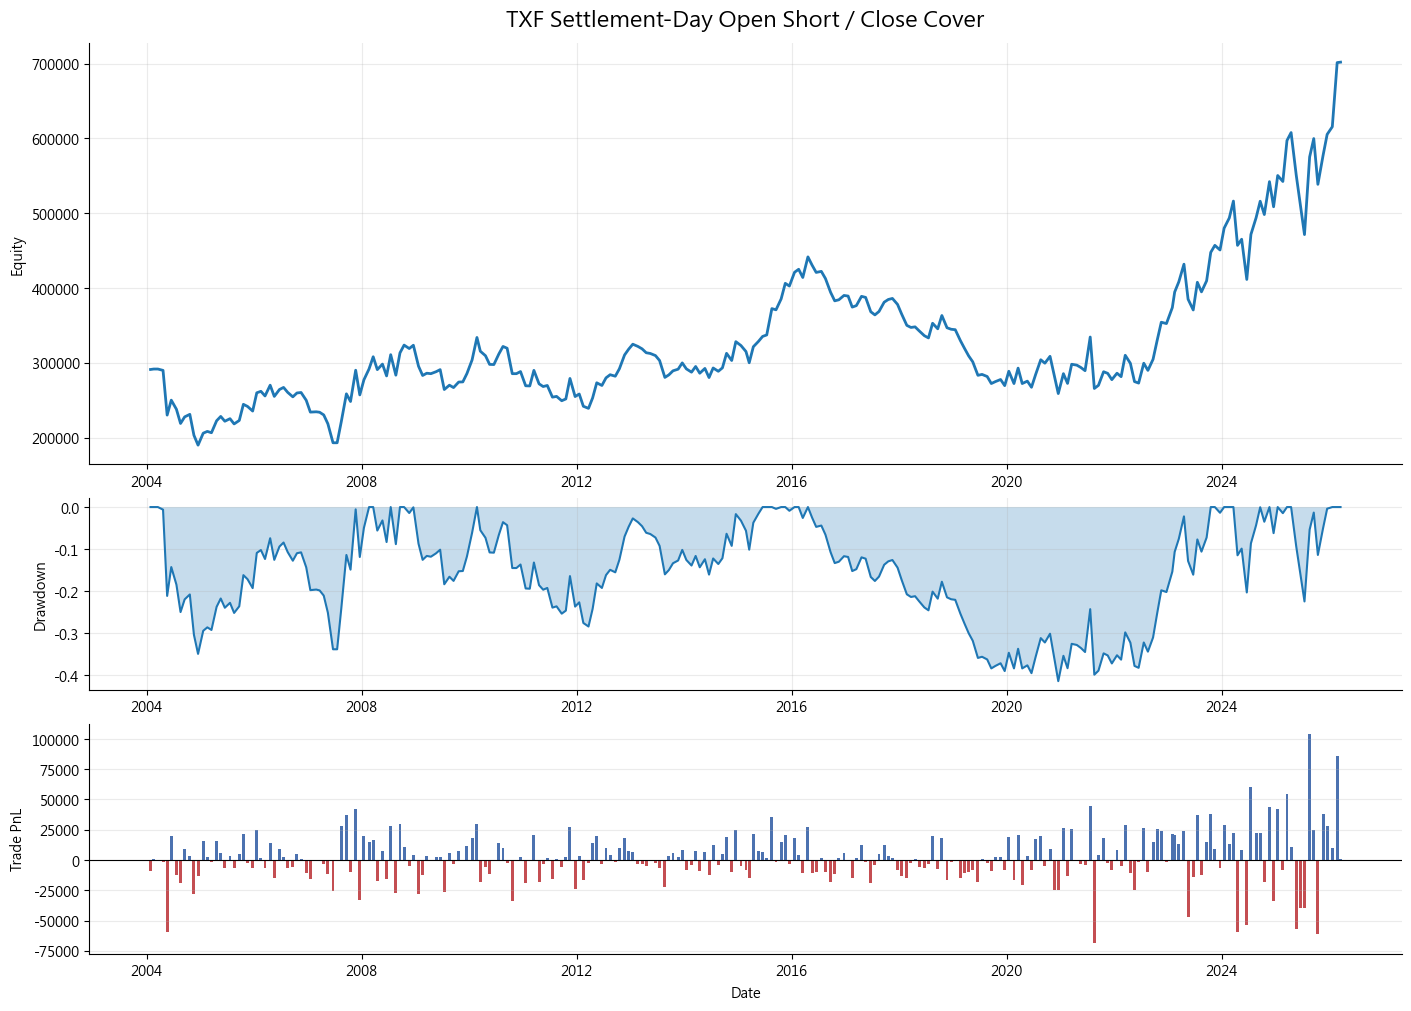

In [37]:
txf_daily_df = pd.read_csv("台指期收盤.csv", index_col=0, parse_dates=True)

settlement_df = get_settlement_dates(
    "2004-01-01",
    "2026-03-30",
    trading_days=txf_daily_df.index
)

result_big = backtest_open_short_close_cover(txf_daily_df, settlement_df, multiplier=200)


df_big = prepare_backtest_dataframe(result_big, initial_capital=300000)
summary_big = performance_summary(df_big, initial_capital=300000)

print(summary_big)
plot_professional_tearsheet(
    df_big,
    initial_capital=300000,
    title="TXF Settlement-Day Open Short / Close Cover"
)

In [38]:
import pandas as pd

# === 月份統計（核心一行） ===
monthly = result_big.assign(
    month=lambda x: pd.to_datetime(x["date"]).dt.month
).groupby("month")["pnl_money"].agg(
    N="count",
    Win=lambda x: (x > 0).sum(),
    勝率=lambda x: (x > 0).mean(),
    平均損益="mean",
    累積損益="sum"
).reset_index()

# === 排序 + 欄位順序 ===
monthly = monthly.sort_values("month")[["month","N","Win","勝率","平均損益","累積損益"]]

# === 格式美化 ===
monthly["勝率"] = monthly["勝率"].map(lambda x: f"{x:.2%}")
monthly["平均損益"] = monthly["平均損益"].round(0).astype(int)
monthly["累積損益"] = monthly["累積損益"].round(0).astype(int)

# === 顯示 ===
print("\n=== 月結算日策略 月度統計2004-2026 ===")
print(monthly.to_string(index=False))


=== 月結算日策略 月度統計2004-2026 ===
 month  N  Win     勝率  平均損益    累積損益
     1 23   14 60.87%  7165  164800
     2 23   10 43.48%  1887   43400
     3 23   12 52.17%  6252  143800
     4 22    9 40.91% -1018  -22400
     5 22    8 36.36% -9045 -199000
     6 22    5 22.73% -9191 -202200
     7 22   14 63.64%  7018  154400
     8 22   11 50.00%  2891   63600
     9 22   12 54.55%  5491  120800
    10 22   17 77.27%  3636   80000
    11 22   14 63.64%  6573  144600
    12 22    8 36.36% -4082  -89800


交易次數: 201
勝率: 0.5622
總損益: 893000
               Metric       Value
0          Start Date  2004-01-27
1            End Date  2026-03-18
2              Trades         201
3            Win Rate      56.22%
4  Avg Win / Avg Loss        1.39
5              Sharpe        0.74
6        Max Drawdown     -17.61%
7        Total Return     297.67%
8        Final Equity   1,193,000


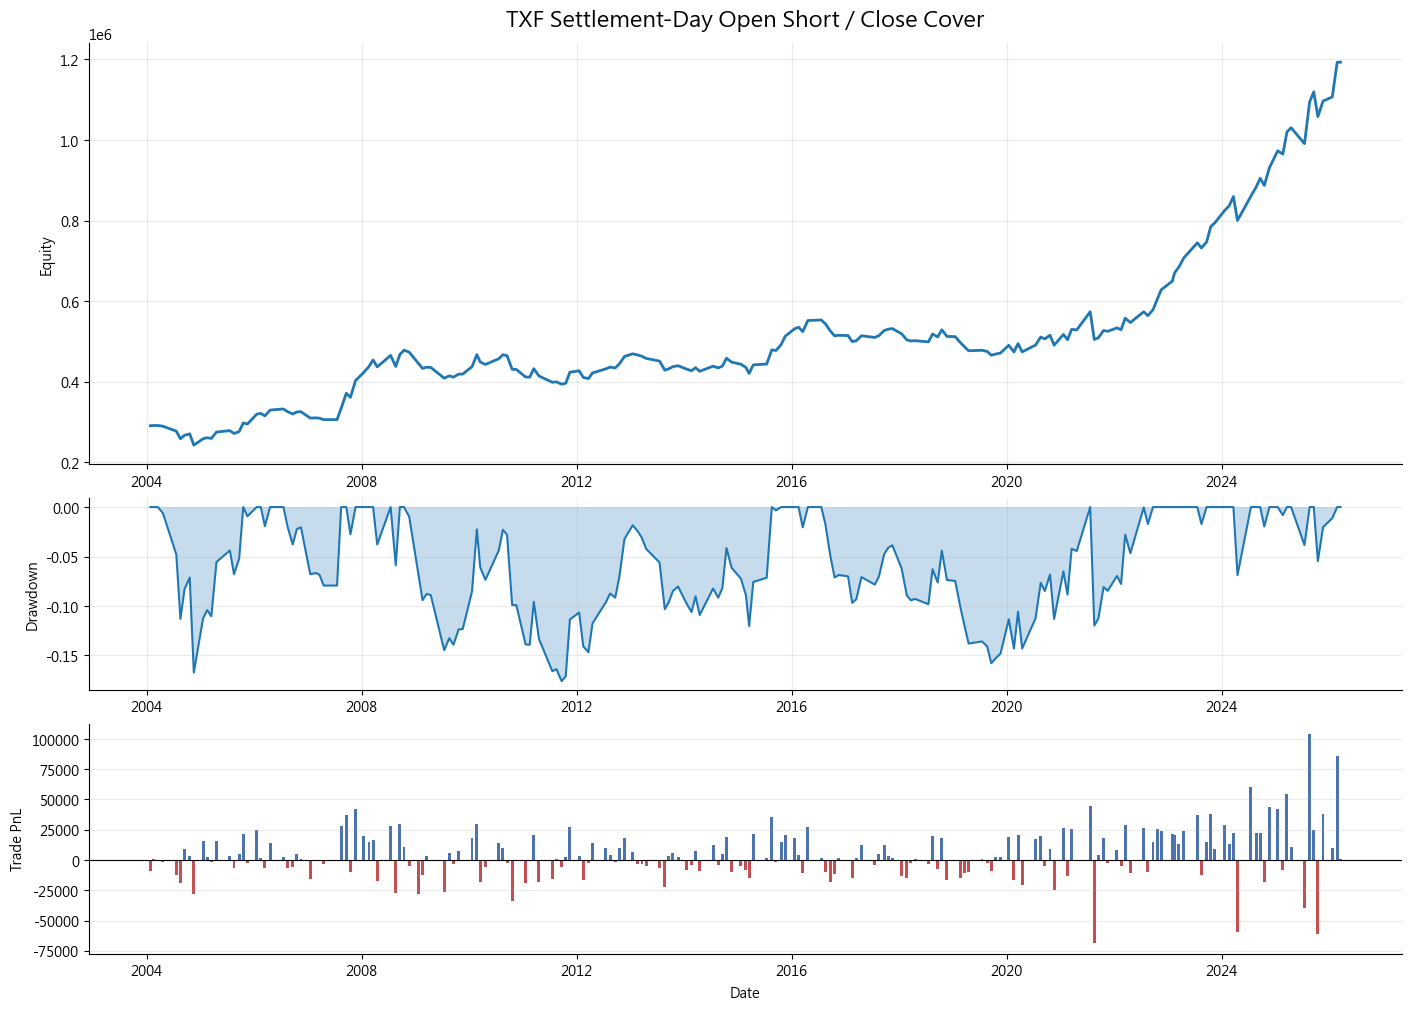

In [41]:
settlement_df = get_settlement_dates(
    "2004-01-01",
    "2026-03-30",
    trading_days=txf_daily_df.index
)

# 🔥 加這一行：過濾掉 5、6、12 月
settlement_df = settlement_df[
    ~pd.to_datetime(settlement_df["settlement_date"]).dt.month.isin([5, 6, 12])
]

result_big = backtest_open_short_close_cover(txf_daily_df, settlement_df, multiplier=200)

df_big = prepare_backtest_dataframe(result_big, initial_capital=300000)
summary_big = performance_summary(df_big, initial_capital=300000)

print(summary_big)
plot_professional_tearsheet(
    df_big,
    initial_capital=300000,
    title="TXF Settlement-Day Open Short / Close Cover"
)

In [43]:
import pandas as pd
import numpy as np
from scipy import stats

# === 月份統計 + 顯著性 ===
monthly = result_big_perf.assign(
    month=lambda x: pd.to_datetime(x["date"]).dt.month
).groupby("month")["pnl_money"].agg(
    N="count",
    Win=lambda x: (x > 0).sum(),
    勝率=lambda x: (x > 0).mean(),
    平均損益="mean",
    累積損益="sum",
    std="std"
).reset_index()

# === t-stat & p-value ===
monthly["t_stat"] = monthly["平均損益"] / (monthly["std"] / np.sqrt(monthly["N"]))
monthly["p_value"] = 2 * (1 - stats.t.cdf(np.abs(monthly["t_stat"]), df=monthly["N"] - 1))

# === 顯著性標記 ===
def significance(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

monthly["sig"] = monthly["p_value"].apply(significance)

# === 排序 & 清理 ===
monthly = monthly.sort_values("month")

# === 格式化 ===
monthly["勝率"] = monthly["勝率"].map(lambda x: f"{x:.2%}")
monthly["平均損益"] = monthly["平均損益"].round(0).astype(int)
monthly["累積損益"] = monthly["累積損益"].round(0).astype(int)
monthly["t_stat"] = monthly["t_stat"].round(2)
monthly["p_value"] = monthly["p_value"].map(lambda x: f"{x:.3f}")

# === 顯示欄位 ===
monthly = monthly[[
    "month", "N", "Win", "勝率", "平均損益", "累積損益",
    "t_stat", "p_value", "sig"
]]

# === 印出 ===
print("\n=== 月份統計（含顯著性） ===")
print(monthly.to_string(index=False))


=== 月份統計（含顯著性） ===
 month  N  Win      勝率   平均損益    累積損益  t_stat p_value sig
     1  6    6 100.00%  24467  146800    5.40   0.003 ***
     2  6    2  33.33%  -1267   -7600   -0.21   0.845    
     3  6    6 100.00%  27633  165800    4.75   0.005 ***
     4  6    2  33.33%  -9600  -57600   -0.81   0.452    
     5  6    2  33.33% -20000 -120000   -1.80   0.133    
     6  6    0   0.00% -20400 -122400   -2.34   0.066   *
     7  6    5  83.33%  24367  146200    1.72   0.146    
     8  6    3  50.00%   9100   54600    0.39   0.711    
     9  6    5  83.33%  12667   76000    2.80   0.038  **
    10  5    4  80.00%  14600   73000    1.56   0.194    
    11  5    3  60.00%  10120   50600    0.87   0.434    
    12  5    0   0.00% -15000  -75000   -2.46   0.069   *
